<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/my-part/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP

## Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Load Dataset

In [2]:
# Load dataset
file_path = "/content/synthetic_data_cleaned_feature_engineered.csv"
df = pd.read_csv(file_path, sep="|")
#df = pd.read_csv(file_path)
# View first rows
df.head()


,Customer_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Loan_Officer_Note,Default_Status,Occupation,Has_Asset,Risk_Flag,DTI_Ratio,Log_Income
0,CUST-4321,55,120000,770,160000,48,Teaching assistant facing sudden hospital bill...,1,Education,0,0,1.333322,11.695255
1,CUST-2056,40,150000,780,90000,36,Photographer inherits art collection easing fi...,0,Other,0,0,0.599996,11.918397
2,CUST-9812,34,75000,660,110000,48,Retail store owner deals daily challenges due ...,1,Service,0,0,1.466647,11.225257
3,CUST-8132,28,32000,710,60000,24,Software developer secures bonus which helps c...,0,Tech,1,0,1.874941,10.373522
4,CUST-0543,45,80000,820,240000,72,Business consultant recently benefited from su...,1,Business,0,0,2.999963,11.289794


In [3]:
df.isnull().sum()


,0
Customer_ID,0
Age,0
Annual_Income,0
Credit_Score,0
Loan_Amount,0
Loan_Term_Months,0
Loan_Officer_Note,0
Default_Status,0
Occupation,0
Has_Asset,0


## Data Preprocessing

### Train-Test Split (80% Train, 20% Test)

In [4]:
X = df.drop(columns=["Default_Status"])
y = df["Default_Status"]
#X = df.drop(columns=["default_risk"])
#y = df["default_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


### Identify categorical and numeric columns


In [5]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numeric columns:", list(numeric_cols))




Categorical columns: ['Customer_ID', 'Loan_Officer_Note', 'Occupation']
Numeric columns: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income']


### Preprocessing Pipeline

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)


## Build MLP Pipeline

In [7]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
       # ("smote", SMOTE(random_state=45)),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=42
        ))
    ]
)


## Train Model

In [8]:
mlp_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount',
       'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio',
       'Log_Income'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Customer_ID', 'Loan_Officer_Note', 'Occupation'], dtype='object'))])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                               random_state=42))])

## Evaluation

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
# Predict class labels (0 or 1)
y_pred = mlp_pipeline.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print("Model Evaluation (MLP Classifier)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC:, {auc:.4f}" )



Model Evaluation (MLP Classifier)
Accuracy : 0.7945
Precision: 0.7857
Recall   : 0.7097
F1-score : 0.7458
ROC-AUC:, 0.7834


### Evaluation Report

In [11]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       126
           1       0.79      0.71      0.75        93

    accuracy                           0.79       219
   macro avg       0.79      0.78      0.79       219
weighted avg       0.79      0.79      0.79       219



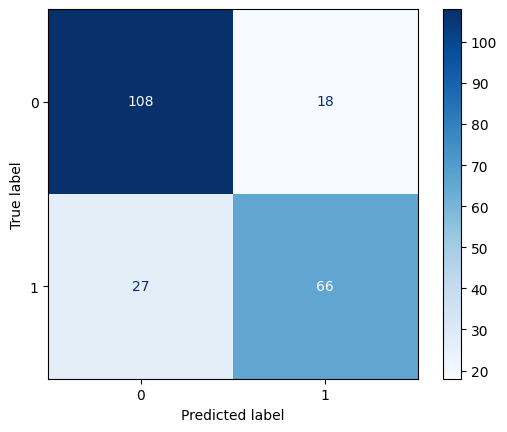

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=[0, 1]
)

disp.plot(cmap="Blues")  # blue gradient
plt.show()


## Hypertune

### Optuna

In [13]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score


In [21]:
def objective(trial):

    hidden_layer_sizes = (
        trial.suggest_int("n_units_l1", 32, 128),
        trial.suggest_int("n_units_l2", 16, 64)
    )

    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)

    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=300,
        random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", mlp)
        ]
    )

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)


[I 2026-01-18 15:02:17,320] A new study created in memory with name: no-name-95b89510-7aae-4cad-aec1-a05db5264541
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[I 2026-01-18 15:02:18,965] Trial 0 finished with value: 0.7753820429500159 and parameters: {'n_units_l1': 35, 'n_units_l2': 58, 'alpha': 0.0017808906811087749, 'learning_rate_init': 0.009475041261480383}. Best 

In [ ]:
print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)


In [ ]:
correlation_matrix = df[numeric_cols].corr()
print("Correlation Matrix of Numerical Features:")
print(correlation_matrix)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Part B: The LLM Analysis (The Insight)
Use LLMs to summarise findings, provide insights, and interpret feature importance.

In [19]:
# ==========================================
# PART B: Automated LLM Analysis
# ==========================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline


# Install bitsandbytes if not already installed or to ensure latest version
!pip install -U bitsandbytes

print("⏳ Loading LLM for Analysis...")

# 1. Setup Model (Same setup as your Data Gen lab)
model_name = "microsoft/Phi-3-mini-4k-instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto"
)

  Using cached bitsandbytes-0.49.1-py3-none-manylinux_2_24_x86_64.whl.metadata (10 kB)
Using cached bitsandbytes-0.49.1-py3-none-manylinux_2_24_x86_64.whl (59.1 MB)
  Attempting uninstall: bitsandbytes
    Found existing installation: bitsandbytes 0.41.1
    Uninstalling bitsandbytes-0.41.1:
      Successfully uninstalled bitsandbytes-0.41.1
⏳ Loading LLM for Analysis...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [20]:
# 2. Construct the Prompt Dynamically
# We inject the python variables from Part A directly into the string.
analysis_prompt = f"""[INST] You are a Data Science Expert. I have trained a Naive Bayes model to predict Loan Defaults.
Please analyze the performance metrics and feature importance listed below.

### MODEL PERFORMANCE:
- Accuracy: {metric_accuracy:.2%}
- Recall: {metric_recall:.2%} (Ability to catch actual defaulters)
- F1-Score: {metric_f1:.4f}
- ROC-AUC: {metric_auc:.4f}

### TOP 5 MOST IMPORTANT FEATURES:
{top_features_str}

### INSTRUCTIONS:
1. Summarize the model's performance. Is it good for risk management?
2. Interpret the Feature Importance. Why are these specific features predictive of loan default?
3. Provide one business recommendation based on these findings.
[/INST]"""

NameError: name 'metric_accuracy' is not defined

In [ ]:
# 3. Generate the Analysis
print("🤖 Generating Analysis from LLM...")

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=1024,
    do_sample=True,
    temperature=0.1,
    repetition_penalty=1.0 # <--- ADDED: Helps prevent getting stuck/repeating
)

output = generator(analysis_prompt)
generated_text = output[0]['generated_text']

In [ ]:
# 4. Display Result
print("\n" + "="*50)
print("📝 LLM AUTOMATED FINDINGS & INSIGHTS")
print("="*50)
# Clean up output to show only the response
print(generated_text.split("[/INST]")[-1].strip())